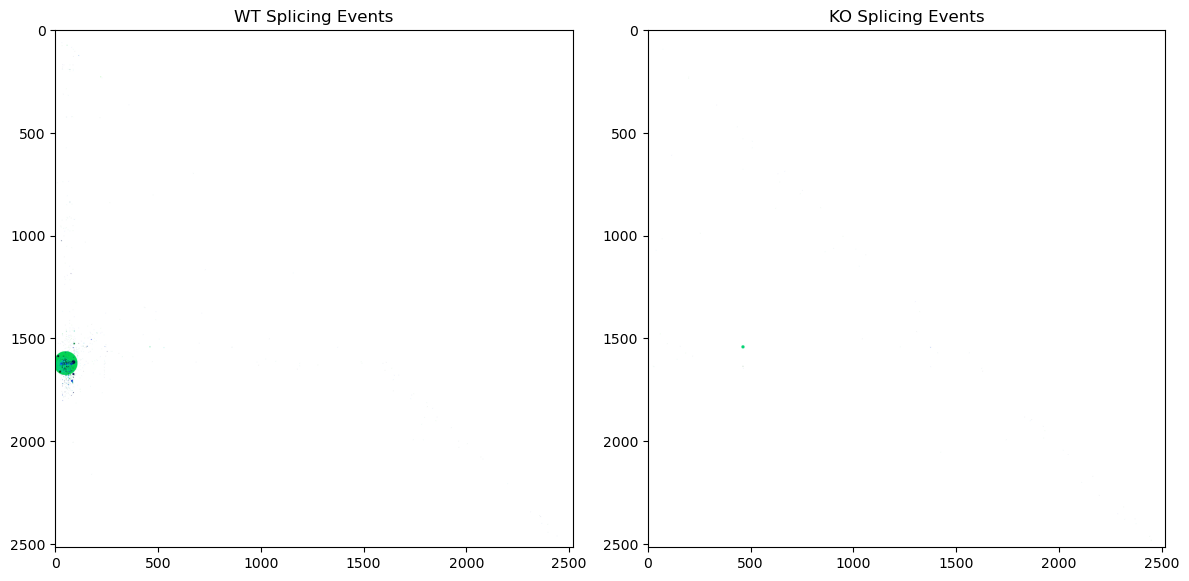

In [10]:
import pandas as pd
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


os.chdir('/data2/zhoulab/fanweiliang/mouse_IER1_splicing')

gene_size = 0
gene_sequence = ''

with open('results/SOS_splicing_HEK293T/references/HEK293T_Tc1_GFP.fa') as f:
    for line in f:
        if line.startswith('>'):
            continue
        gene_sequence += line.strip()
        gene_size += len(line.strip())

wt_splicing = pd.read_csv('sos.wt.tsv', sep='\t', header=None, names=['chr', 'start', 'end', 'count'])
ko_splicing = pd.read_csv('sos.ko.tsv', sep='\t', header=None, names=['chr', 'start', 'end', 'count'])

wt_sorted = wt_splicing.sort_values(by=['count'], ascending=False)
ko_sorted = ko_splicing.sort_values(by=['count'], ascending=False)


def get_acceptor_donor_motif(row):
    acceptor_motif = gene_sequence[row['end'] - 2:row['end']].upper()
    donor_motif = gene_sequence[row['start']:row['start'] + 2].upper()
    return f'{acceptor_motif}_{donor_motif}'


all_motifs = set(i + j for i in 'ATGC' for j in 'ATGC')
all_ac_dn_motifs = set(f'{i}_{j}' for i in all_motifs for j in all_motifs)

# assign 4096 color motif(64*64) => RGB(16*16*16)
all_colors = [(r,g,b) for r in range(4, 256, 16) for g in range(4, 256, 16) for b in range(4, 256, 16)]
color_map = {motif: all_colors[i] for i, motif in enumerate(all_ac_dn_motifs)}

wt_sorted['motif'] = wt_sorted.apply(get_acceptor_donor_motif, axis=1)
ko_sorted['motif'] = ko_sorted.apply(get_acceptor_donor_motif, axis=1)
wt_sorted['color'] = wt_sorted['motif'].apply(lambda x: color_map[x])
ko_sorted['color'] = ko_sorted['motif'].apply(lambda x: color_map[x])

# create blank images
wt_img = np.ones((gene_size, gene_size, 3), dtype=np.uint8) * 255
ko_img = np.ones((gene_size, gene_size, 3), dtype=np.uint8) * 255

for _, row in wt_sorted.iterrows():
    cv2.circle(wt_img, (row['start'], row['end']), radius=row['count'] // 4, color=row['color'], thickness=-1)

for _, row in ko_sorted.iterrows():
    cv2.circle(ko_img, (row['start'], row['end']), radius=row['count'] // 4, color=row['color'], thickness=-1)


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('WT Splicing Events')
plt.imshow(wt_img)

plt.subplot(1, 2, 2)
plt.title('KO Splicing Events')
plt.imshow(ko_img)

plt.tight_layout()
plt.show()
